In [1]:
import sympy

In [2]:
from sympy import symbols, I, Integer

# formal expansions 

In [3]:
z, u0, u1, u2, theta, phi = symbols('z u0 u1 u2 theta phi')

In [4]:
def sn(n): 
    ndif = sympy.simplify(sympy.diff( 1/((z-u1)*(z-u2))**(n), z, n-1))/sympy.factorial(n)
    return sympy.simplify(ndif.subs({z:-u1-u2}))

In [5]:
Dz, E, Bx, By, Bz, B = symbols('Dz E Bx By Bz B')

In [6]:
q = Dz**3 - 9 * Dz * E**2

In [7]:
avdet = z**3 - (B**2 + E**2 + Integer(9) * Dz**2/Integer(27)) * z + Integer(2)*q/Integer(27)
avdet

2*Dz**3/27 - 2*Dz*E**2/3 + z**3 - z*(B**2 + Dz**2/3 + E**2)

In [8]:
Delta = (3*B**2+Dz**2+3*E**2)**3 - (Dz**3 - 9*Dz*E**2)**2
Delta

-(Dz**3 - 9*Dz*E**2)**2 + (3*B**2 + Dz**2 + 3*E**2)**3

In [9]:
omega = sympy.exp(Integer(2) * sympy.pi * I / Integer(3))
omega

exp(2*I*pi/3)

In [10]:
w2 = ( (-q + I * sympy.sqrt(Delta))**(Integer(1)/Integer(3)) + (-q - I * sympy.sqrt(Delta))**(Integer(1)/Integer(3)) ) / Integer(3)

In [11]:
w1 = ( omega**2 * (-q + I * sympy.sqrt(Delta))**(Integer(1)/Integer(3)) + omega * (-q - I * sympy.sqrt(Delta))**(Integer(1)/Integer(3)) ) / Integer(3)

In [12]:
w0 = ( omega * (-q + I * sympy.sqrt(Delta))**(Integer(1)/Integer(3)) + omega**2 * (-q - I * sympy.sqrt(Delta))**(Integer(1)/Integer(3)) ) / Integer(3)

In [13]:
sympy.simplify( avdet.subs( {z: w2} ) ).subs({Dz: 1, E: 0.1, B: 0.7}).evalf()

2.5667495125585e-17 + 0.e-41*I

In [14]:
sympy.simplify( avdet.subs( {z: w1} ) ).subs({Dz: 1, E: 0.1, B: 0.7}).evalf()

2.8731860085344e-18 - 1.03836931433431e-41*I

In [15]:
sympy.simplify( avdet.subs( {z: w0} ) ).subs({Dz: 1, E: 0.1, B: 1.7}).evalf()

8.32193290793934e-16 - 1.24032071538815e-35*I

In [16]:
epsilon = Dz*(2*Bz**2 - By**2 - Bx**2)/3 + E*(Bx**2 - By**2)

In [17]:
dxyz = sympy.simplify( epsilon.subs({Bx: B * sympy.sin(theta) * sympy.cos(phi),
              By: B * sympy.sin(theta) * sympy.sin(phi),
              Bz: B * sympy.cos(theta)
             } ) )
dxyz

B**2*(-Dz*(3*sin(theta)**2 - 2)/3 + E*sin(theta)**2*cos(2*phi))

In [18]:
def epsilon_n(n):
    return sympy.simplify( sympy.integrate( dxyz**n * sympy.sin(theta), (phi, 0, 2 * sympy.pi), (theta, 0, sympy.pi) ) / (4 * sympy.pi) )

In [567]:
epsilon_n(4)

16*B**8*(Dz**4 + 6*Dz**2*E**2 + 9*E**4)/945

In [89]:
Nmax = 7

In [90]:
epsilon_list = [ ]
for n in range(Nmax):
    epsilon_list.append( epsilon_n(n) )
    print(n)

0
1
2
3
4
5
6


In [54]:
epsilon_list[2]

4*B**4*(Dz**2 + 3*E**2)/45

In [55]:
epsilon_list[3]

16*B**6*Dz*(Dz**2 - 9*E**2)/945

In [56]:
epsilon_list[4]

16*B**8*(Dz**4 + 6*Dz**2*E**2 + 9*E**4)/945

In [57]:
epsilon_list[5]

128*B**10*Dz*(Dz**4 - 6*Dz**2*E**2 - 27*E**4)/18711

In [91]:
sn_list = [ u0 ]
for n in range(1,Nmax):
    sn_list.append( sn(n) )

In [60]:
sn_list[1]

1/((u1 + 2*u2)*(2*u1 + u2))

In [61]:
sn_list[2]

3*(u1 + u2)/((u1 + 2*u2)**3*(2*u1 + u2)**3)

In [62]:
sn_list[3]

(2*(u1 + 2*u2)**2 + 3*(u1 + 2*u2)*(2*u1 + u2) + 2*(2*u1 + u2)**2)/((u1 + 2*u2)**5*(2*u1 + u2)**5)

In [92]:
utot = -u1-u2
for n in range(1, Nmax):
    utot += epsilon_list[n] * sn_list[n]

In [574]:
utot

1024*B**20*(161*Dz**10 + 255*Dz**8*E**2 + 5850*Dz**6*E**4 + 47790*Dz**4*E**6 + 91125*Dz**2*E**8 + 19683*E**10)*(34*(u1 + 2*u2)**9 + 170*(u1 + 2*u2)**8*(2*u1 + u2) + 440*(u1 + 2*u2)**7*(2*u1 + u2)**2 + 770*(u1 + 2*u2)**6*(2*u1 + u2)**3 + 1001*(u1 + 2*u2)**5*(2*u1 + u2)**4 + 1001*(u1 + 2*u2)**4*(2*u1 + u2)**5 + 770*(u1 + 2*u2)**3*(2*u1 + u2)**6 + 440*(u1 + 2*u2)**2*(2*u1 + u2)**7 + 170*(u1 + 2*u2)*(2*u1 + u2)**8 + 34*(2*u1 + u2)**9)/(2119203*(u1 + 2*u2)**19*(2*u1 + u2)**19) + 20480*B**18*Dz*(197*Dz**8 - 216*Dz**6*E**2 - 8262*Dz**4*E**4 - 46656*Dz**2*E**6 - 45927*E**8)*(26*(u1 + 2*u2)**8 + 117*(u1 + 2*u2)**7*(2*u1 + u2) + 273*(u1 + 2*u2)**6*(2*u1 + u2)**2 + 429*(u1 + 2*u2)**5*(2*u1 + u2)**3 + 495*(u1 + 2*u2)**4*(2*u1 + u2)**4 + 429*(u1 + 2*u2)**3*(2*u1 + u2)**5 + 273*(u1 + 2*u2)**2*(2*u1 + u2)**6 + 117*(u1 + 2*u2)*(2*u1 + u2)**7 + 26*(2*u1 + u2)**8)/(82648917*(u1 + 2*u2)**17*(2*u1 + u2)**17) + 256*B**16*(95*Dz**8 + 276*Dz**6*E**2 + 4266*Dz**4*E**4 + 14580*Dz**2*E**6 + 5103*E**8)*(13*(u1 +

# computing derivatives

In [93]:
dutotdu1 = sympy.simplify(sympy.diff(utot, u1))

In [94]:
dutotdu2 = sympy.simplify(sympy.diff(utot, u2))

In [95]:
dutotdE = sympy.simplify(sympy.diff(utot, E))

In [96]:
dutotdDz = sympy.simplify(sympy.diff(utot, Dz))

In [97]:
dw0dE = sympy.simplify(sympy.diff(w0, E))

In [98]:
dw0dDz = sympy.simplify(sympy.diff(w0, Dz))

In [99]:
dw2dE = sympy.simplify(sympy.diff(w2, E))

In [100]:
dw2dDz = sympy.simplify(sympy.diff(w2, Dz))

In [101]:
dw1dE = sympy.simplify(sympy.diff(w1, E))

In [102]:
dw1dDz = sympy.simplify(sympy.diff(w1, Dz))

# exporting code 

In [33]:
from sympy.printing.pycode import PythonCodePrinter

def print_code(expr, func_name, args, real=False):
    printer = PythonCodePrinter({
        "user_functions": {
            "sin": "cmath.sin",
            "cos": "cmath.cos",
            "exp": "cmath.exp",
        }
    })

    s, r = sympy.cse(expr)
    f = [*s, ("result", r[0])]

    lines = []
    for name, rhs in f:
        lines.append(f"{name} = {printer.doprint(expr=rhs)}")
    if real:
        lines.append("return result.real")
    else:
        lines.append("return result")
    func_code = f"def {func_name}({args}):\n    " + "\n    ".join(lines)
    return func_code

In [103]:
code_avdet = print_code(avdet, "tisoavdet", "z, B, Dz, E")
code_w0 = print_code(w0, "tisow0", "B, Dz, E", real=True)
code_w1 = print_code(w1, "tisow1", "B, Dz, E", real=True)
code_w2 = print_code(w2, "tisow2", "B, Dz, E", real=True)
code_w0dE = print_code(dw0dE, "tisow0dE", "B, Dz, E", real=True)
code_w0dDz = print_code(dw0dDz, "tisow0dDz", "B, Dz, E", real=True)
code_w1dE = print_code(dw1dE, "tisow1dE", "B, Dz, E", real=True)
code_w1dDz = print_code(dw1dDz, "tisow1dDz", "B, Dz, E", real=True)
code_w2dE = print_code(dw2dE, "tisow2dE", "B, Dz, E", real=True)
code_w2dDz = print_code(dw2dDz, "tisow2dDz", "B, Dz, E", real=True)
code_utot = print_code(utot, "tisoutot", "u1, u2, B, Dz, E", real=True)
code_utotdu1 = print_code(dutotdu1, "tisoutotdu1", "u1, u2, B, Dz, E")
code_utotdE = print_code(dutotdE, "tisoutotdE", "u1, u2, B, Dz, E")
code_utotdDz = print_code(dutotdDz, "tisoutotdDz", "u1, u2, B, Dz, E")


In [104]:
exec(code_avdet)
exec(code_w0)
exec(code_w1)
exec(code_w2)
exec(code_w0dE)
exec(code_w0dDz)
exec(code_w1dE)
exec(code_w1dDz)
exec(code_w2dE)
exec(code_w2dDz)
exec(code_utot)
exec(code_utotdu1)
exec(code_utotdE)
exec(code_utotdDz)


In [105]:
with open("tiso7.py", "w") as f:
    f.write(code_avdet + "\n\n")
    f.write(code_w0 + "\n\n")
    f.write(code_w1 + "\n\n")
    f.write(code_w2 + "\n\n")
    f.write(code_w0dE + "\n\n")
    f.write(code_w0dDz + "\n\n")
    f.write(code_w1dE + "\n\n")
    f.write(code_w1dDz + "\n\n")
    f.write(code_w2dE + "\n\n")
    f.write(code_w2dDz + "\n\n")
    f.write(code_utot + "\n\n")
    f.write(code_utotdu1 + "\n\n")
    f.write(code_utotdE + "\n\n")
    f.write(code_utotdDz + "\n\n")   

In [43]:
import math
import cmath

In [44]:
tisoavdet(tisow0(0.3, 1., 0.1), 0.3, 1., 0.1)

2.220446049250313e-16

In [46]:
tisoavdet(tisow1(0.3, 1., 0.1), 0.3, 1., 0.1)

-4.163336342344337e-17

In [106]:
def alambda0(B, Dz, E):
    return tisoutot( tisow1(B, Dz, E), tisow2(B, Dz, E), B, Dz, E)
def alambda1(B, Dz, E):
    return tisoutot( tisow0(B, Dz, E), tisow2(B, Dz, E), B, Dz, E)
def alambda2(B, Dz, E):
    return tisoutot( tisow0(B, Dz, E), tisow1(B, Dz, E), B, Dz, E)

def dlambda0dDz(B, Dz, E):
    u1 = tisow1(B, Dz, E)
    u2 = tisow2(B, Dz, E)
    return tisoutotdDz(u1, u2, B, Dz, E) + tisoutotdu1(u1, u2, B, Dz, E) * tisow1dDz(B, Dz, E) +  tisoutotdu1(u2, u1, B, Dz, E) * tisow2dDz(B, Dz, E)
def dlambda1dDz(B, Dz, E):
    u1 = tisow0(B, Dz, E)
    u2 = tisow2(B, Dz, E)
    return tisoutotdDz(u1, u2, B, Dz, E) + tisoutotdu1(u1, u2, B, Dz, E) * tisow0dDz(B, Dz, E) +  tisoutotdu1(u2, u1, B, Dz, E) * tisow2dDz(B, Dz, E)
def dlambda2dDz(B, Dz, E):
    u1 = tisow0(B, Dz, E)
    u2 = tisow1(B, Dz, E)
    return tisoutotdDz(u1, u2, B, Dz, E) + tisoutotdu1(u1, u2, B, Dz, E) * tisow0dDz(B, Dz, E) +  tisoutotdu1(u2, u1, B, Dz, E) * tisow1dDz(B, Dz, E)


def dlambda0dЕ(B, Dz, E):
    u1 = tisow1(B, Dz, E)
    u2 = tisow2(B, Dz, E)
    return tisoutotdE(u1, u2, B, Dz, E) + tisoutotdu1(u1, u2, B, Dz, E) * tisow1dE(B, Dz, E) +  tisoutotdu1(u2, u1, B, Dz, E) * tisow2dE(B, Dz, E)

def dlambda1dЕ(B, Dz, E):
    u1 = tisow0(B, Dz, E)
    u2 = tisow2(B, Dz, E)
    return tisoutotdE(u1, u2, B, Dz, E) + tisoutotdu1(u1, u2, B, Dz, E) * tisow0dE(B, Dz, E) +  tisoutotdu1(u2, u1, B, Dz, E) * tisow2dE(B, Dz, E)

def dlambda2dЕ(B, Dz, E):
    u1 = tisow0(B, Dz, E)
    u2 = tisow1(B, Dz, E)
    return tisoutotdE(u1, u2, B, Dz, E) + tisoutotdu1(u1, u2, B, Dz, E) * tisow0dE(B, Dz, E) +  tisoutotdu1(u2, u1, B, Dz, E) * tisow1dE(B, Dz, E)


# example simulations

In [107]:
import numpy as np
bvec = np.arange(0, 6, 0.01)

l0 = np.vectorize(alambda0,excluded=[1,2])( bvec, 1, 0.05 )
l1 = np.vectorize(alambda1,excluded=[1,2])( bvec, 1, 0.05 )
l2 = np.vectorize(alambda2,excluded=[1,2])( bvec, 1, 0.05 )

d0dDz = np.vectorize(dlambda0dDz,excluded=[1,2])( bvec, 1, 0.05 )
d1dDz = np.vectorize(dlambda1dDz,excluded=[1,2])( bvec, 1, 0.05 )
d2dDz = np.vectorize(dlambda2dDz,excluded=[1,2])( bvec, 1, 0.05 )


d0dE = np.vectorize(dlambda0dЕ,excluded=[1,2])( bvec, 1, 0.05 )
d1dE = np.vectorize(dlambda1dЕ,excluded=[1,2])( bvec, 1, 0.05 )
d2dE = np.vectorize(dlambda2dЕ,excluded=[1,2])( bvec, 1, 0.05 )


In [108]:
np.savetxt("pyavD1E0p05n6.dat", np.vstack( (bvec, l0, l1, l2, d0dDz, d1dDz, d2dDz, d0dE, d1dE, d2dE) ).transpose(), header="randtriplet.ipynb")

In [554]:
bvec.shape

(600,)

In [543]:
import matplotlib.pyplot as plt

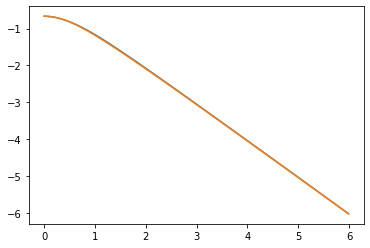

In [545]:
plt.plot(bvec, l0)
plt.plot(bvec, lw0)

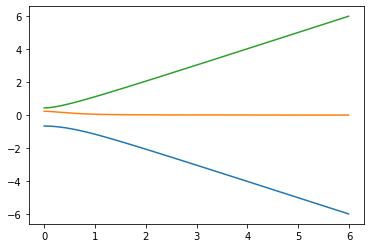

In [546]:
plt.plot(bvec, l0)
plt.plot(bvec, l1)
plt.plot(bvec, l2)


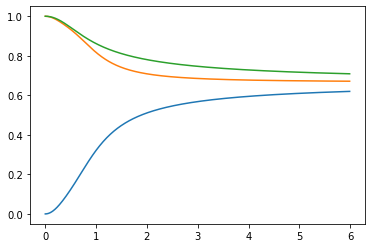

In [547]:
plt.plot(bvec, d0dDz+2./3.)
plt.plot(bvec, d1dDz+2./3.)
plt.plot(bvec, d2dDz+2./3.)

#plt.plot(bvec, d0dE)

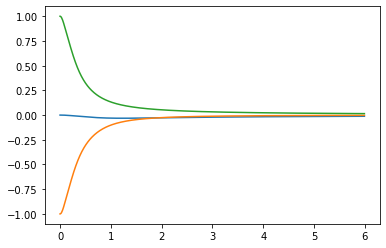

In [548]:
plt.plot(bvec, d0dE)
plt.plot(bvec, d1dE)
plt.plot(bvec, d2dE)

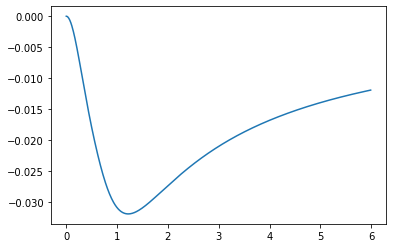

In [549]:
plt.plot(bvec, d0dE)
